In [1]:
import os
os.listdir('.')

['weil_sensitivity_map.json',
 '.kernel_llm_logs_1.txt',
 'memory',
 '.prompts',
 'zeta_zeros_5000_dps50.npy',
 '.config',
 'ldh_def.py']

In [2]:
import json
with open('weil_sensitivity_map.json') as f:
 smap = json.load(f)
print(json.dumps(smap, indent=2)[:3000])

{
 "description": "Sensitivity map of Weil quadratic form Q=M_zeros-M_arith for \u03b6_\u03b4 (first 20 zeta zeros shifted to Re=1/2+\u03b4)",
 "parameters": {
 "J": 10,
 "prime_bound": 1000,
 "T0_grid": [
 4.134725141734695,
 6.134725141734695,
 8.134725141734695,
 10.134725141734695,
 12.134725141734695,
 14.134725141734695,
 16.134725141734695,
 18.134725141734695,
 20.134725141734695,
 22.134725141734695,
 24.134725141734695,
 26.134725141734695,
 28.134725141734695,
 30.134725141734695,
 32.13472514173469,
 34.13472514173469,
 36.13472514173469,
 38.13472514173469,
 40.13472514173469,
 42.13472514173469,
 44.13472514173469,
 46.13472514173469,
 48.13472514173469,
 50.13472514173469,
 52.13472514173469,
 54.13472514173469,
 56.13472514173469,
 58.13472514173469,
 60.13472514173469,
 62.13472514173469,
 64.13472514173469,
 66.13472514173469,
 68.13472514173469,
 70.13472514173469,
 72.13472514173469,
 74.13472514173469,
 76.13472514173469,
 78.13472514173469,
 80.13472514173469,
 82

In [3]:
print(smap.get('notes', ''))
print('---lambda_min_at_optimal---')
print(json.dumps(smap.get('lambda_min_at_optimal', {}), indent=2))

['For T0 in [γ1+2, γ20+2] (~16-78) with σ=1 or 2, the smallest tested δ=0.05 is reliably detected.', 'For σ=4 the basis is too broad and averages out the shifted-zero signal; sensitivity degrades to δ>=0.1.', 'For T0 outside the shifted-zero range, sensitivity drops to NaN (no detection) within δ <= 0.5.', 'At optimal (T0=46.13, σ=1): ζ, L(χ), L(Δ), and L_DH all have |λ_min| ~ 1e-12 (numerical noise), while ζ_δ at δ=0.05 yields λ_min = -0.51 — a 12-order-of-magnitude separation.', 'L_DH evaluated at this T0 does NOT show its known off-critical anomaly because the anomaly is at T0≈85.7 (Spira zero); confirmed in cell #20 with explicit inclusion of off-critical pair at T0=85.7 σ=2.', 'M_arith for L_DH is approximated as ≈0 since the test functions are far from the support of log p; analyses near T0=85.7 require careful M_arith construction (validated already in r15).']
---lambda_min_at_optimal---
{}


In [4]:
print(list(smap.keys()))

['description', 'parameters', 'sensitivity_map', 'optimal_point', 'validation_at_optimal', 'notes']


In [5]:
print(json.dumps(smap['optimal_point'], indent=2))
print(json.dumps(smap['validation_at_optimal'], indent=2))

{
 "T0": 46.1347251417347,
 "sigma": 1.0
}
{
 "zeta": {
 "lambda_min": -1.1125538813640506e-13,
 "lambda_max": 71033.9926247301,
 "trace_Mz": 78127.0457390419,
 "trace_Ma": 0.0
 },
 "lchi": {
 "lambda_min": 1.1313336279823418e-12,
 "lambda_max": 67750.5836808874,
 "trace_Mz": 75448.81896313878,
 "trace_Ma": 0.0
 },
 "ldelta": {
 "lambda_min": -7.331555682683376e-12,
 "lambda_max": 93246.17618925296,
 "trace_Mz": 104923.04583632675,
 "trace_Ma": 0.0
 },
 "zeta_delta_0.05": {
 "lambda_min": -0.5103042600417259,
 "lambda_max": 71133.72504389338,
 "trace_Mz": 78192.69048657286,
 "trace_Ma": 0.0
 },
 "ldh": {
 "lambda_min": 2.1732839542078953e-12,
 "lambda_max": 73246.84952351428,
 "trace_Mz": 81746.97677242929,
 "note": "M_arith approximated as 0 (negligible at this T0)"
 }
}


In [6]:
import numpy as np
import mpmath as mp
mp.mp.dps = 50

zeta_zeros = np.load('zeta_zeros_5000_dps50.npy', allow_pickle=True)
print(zeta_zeros.shape, zeta_zeros[0], zeta_zeros[-1])
print(type(zeta_zeros[0]))

(5000,) 14.134725141734693790457251983562470270784257115699 5447.8619983012998564121586734642921676829672006076
<class 'numpy.str_'>


In [7]:
# Reimplement Weil quadratic form Q = M_zeros - M_arith.
# Test basis: h_i(t) = ((t-T0)/sigma)^i * exp(-((t-T0)/sigma)^2 / 2), i=0..J-1
# M_zeros[i,j] = sum_gamma h_i(gamma) h_j(gamma) (using zeros gamma_n's imaginary parts; real shift only changes 
# what's a "zero" for the deformed function). For deformation, zero at s=1/2+delta + i*gamma => 
# contribution structurally is h_i(gamma) modified by Re shift via factor exp(?) — but the report formulation 
# uses test functions evaluated at zero ordinates gamma; deformation enters by shifting the EFFECTIVE arg.
# Read the formula carefully from JSON: test_basis says h_i evaluated at scalars k log p. M_arith from prime side.
# For M_zeros in r15/r19 typical Weil form: sum over zeros rho = beta + i*gamma of h(gamma) h(gamma)^T but with a 
# weighting that depends on beta when beta != 1/2. The standard explicit formula has the zero side as 
# sum_rho \hat{F}(rho), with rho on critical line implying F symmetric. For a real test function F on real line,
# the zero side becomes sum_gamma F(gamma) when zeros are on critical line. For off-line zeros at 1/2+delta+i*gamma,
# the symmetry pair adds an extra weighting.
#
# Looking at the JSON: "M_arith_formula" uses h(k log p) terms. The Weil form for ζ_δ that produces negative 
# eigenvalues likely is constructed in r15 as follows: a real-valued vector basis function vec(h)(t), and 
# M_zeros = sum_gamma_n vec(h)(gamma_n) vec(h)(gamma_n)^T with the deformation modifying which gamma_n's appear 
# (here first 20 zeros shifted but the imaginary part stays — so a real-shift wouldn't change M_zeros that way).
# So the deformation must enter via a different mechanism: maybe duplicating zeros to account for both 
# rho = 1/2+delta+i*gamma and rho' = 1/2-delta+i*gamma (functional equation symmetry). In that case M_zeros gets 
# weighted contributions = 2*h(gamma) h(gamma)^T (same as critical-line case), so still no negativity from M_zeros.
#
# More likely: the explicit formula for Weil is 
# sum_rho h(gamma) where h is even, plus archimedean = sum_p log(p)/p^(k/2) [g(k log p) + g(-k log p)] for g = inverse Fourier of h.
# Q[i,j] becomes a positive form on h via cross-term. For an off-line zero at 1/2+delta+i*gamma, contribution to 
# zero side is cosh(delta * k log p) — hmm getting complicated.
#
# Pragmatic approach: trust the JSON formula. M_arith = sum_{p,k: p^k<=prime_bound} log(p)/sqrt(p^k) * 
# [h(k log p) h(k log p)^T + h(-k log p) h(-k log p)^T]. So M_arith is constructed from primes.
# For M_zeros, the standard construction is sum over zeros of h(gamma) h(gamma)^T (NOT depending on real part).
# So how can ζ_δ give -0.51? The trick is replacing the first 20 zero ordinates with shifted ones... but real-shift
# alone doesn't change imaginary parts. Unless they're shifting THE IMAGINARY PARTS by delta? Or the zeros now 
# don't satisfy explicit formula so Q=M_z-M_a becomes non-PSD because M_a is set based on what the prime side WOULD
# be for the true ζ — but they're checking if shifted zeros satisfy the Weil bound.
#
# Actually: the explicit formula equates the zero sum to the prime+archimedean sum. So M_zeros equals
# M_arith + boundary terms for the TRUE zeta. If we use the FALSE shifted zeros in M_zeros but the TRUE M_arith,
# then Q = M_zeros(shifted) - M_arith(true) is no longer PSD.
# But how does the shift in REAL PART manifest in M_zeros if the imaginary parts gamma_n are unchanged?
#
# Re-read: "ζ_δ for the deformed zeta function with a fixed shift of δ=0.05 on the first 20 zeros".
# In Weil's explicit formula proper version, zero contribution is h(gamma) for zeros at 1/2+i*gamma. For zeros 
# at 1/2+delta + i*gamma (i.e., off-line), the contribution is different — for an even test function F (Fourier 
# transform of h), it's F(gamma - i*delta) + F(gamma + i*delta) on the critical strip representation. Equivalently:
# h_off(gamma; delta) = h evaluated at complex argument, but if h is a real Gaussian polynomial we can analytically 
# continue: h_i(t + i*delta/sigma) effectively. So M_zeros entries for shifted zeros become 
# Re[h_i(gamma + i*delta) h_j(gamma + i*delta)] (or similar). Let's check this gives -0.51 magnitude.
#
# This matches r15/r19 standard treatment. Let me implement: for a zero at 1/2+beta+i*gamma where beta=delta or 0,
# the contribution to M_zeros[i,j] involves the function evaluated with complex shift.

# I'll implement it explicitly based on the Weil explicit formula. For test function pairs (f, g) where 
# g = Fourier transform of f, the zero sum is sum_rho f(gamma_rho - i*(beta-1/2)) with rho = beta+i*gamma.
# For our basis h_i = monomial * Gaussian (real), they extend to complex. Substituting beta=1/2 gives h_i(gamma) real.
# For shifted zeros at 1/2+delta+i*gamma, contribution becomes h_i(gamma - i*delta) plus its conjugate (functional eq).
# But h is REAL on R, so its analytic continuation has h(t - i*delta) complex; pairing gives 
# h_i(gamma-i*delta) h_j(gamma+i*delta) (from functional-equation pair at conjugate location).
# Standard symmetrization: M_zeros entry = sum_zeros Re[h_i(gamma - i*beta) conj(h_j(gamma - i*beta))]
# = sum |h_i(gamma - i*beta)|^2-like with the matrix structure.
# Actually for vector h(t) = (h_0,...,h_{J-1})(t), the M_zeros matrix should be sum_zeros h(gamma-i*beta) h(gamma+i*beta)^T
# (using functional-eq pair). With beta=0, this is h(gamma) h(gamma)^T, real PSD.
# With beta != 0, the matrix becomes h(gamma-i*beta) h(gamma+i*beta)^T which is not symmetric → symmetrize:
# M_zeros = sum_zeros 0.5*(h(g-iβ) h(g+iβ)^T + h(g+iβ) h(g-iβ)^T) = Re[h(g-iβ) h(g+iβ)^T]
# which IS symmetric real. And can have negative eigenvalues since not |v|^2 form anymore.
print('Plan above')

Plan above


In [8]:
# Implement using mpmath for accuracy, but main computation can use float64 since the basis values 
# at gamma_n ~ 46 with sigma=1 and J up to 20 — values stay moderate. Let's use float64 for speed but 
# carry mpmath shift carefully. We'll cross-check zeta result at J=10 against published lambda_min~-1.11e-13.

import numpy as np
from sympy import isprime, primerange

T0 = 46.1347251417347
sigma = 1.0
PRIME_BOUND = 1000

# Load zeta zeros
gammas_str = np.load('zeta_zeros_5000_dps50.npy', allow_pickle=True)
# Use double precision for these zeros; values up to ~5447 — fine for float64
gammas = np.array([float(s) for s in gammas_str])

# Restrict to gammas within half_window = max(20, 6*sigma) of T0
half_window = max(20.0, 6.0*sigma)
mask = np.abs(gammas - T0) <= half_window
gammas_used = gammas[mask]
print(f"Using {len(gammas_used)} zeros near T0={T0}, range {gammas_used.min():.3f} - {gammas_used.max():.3f}")

Using 12 zeros near T0=46.1347251417347, range 30.425 - 65.113


In [9]:
def h_vec_real(t_arr, J, T0, sigma):
 """For real t, returns array shape (len(t_arr), J) with h_i(t) = ((t-T0)/sigma)^i * exp(-u^2/2), u=(t-T0)/sigma."""
 u = (t_arr - T0) / sigma
 gauss = np.exp(-u**2 / 2.0)
 out = np.zeros((len(t_arr), J))
 pow_u = np.ones_like(u)
 for i in range(J):
 out[:, i] = pow_u * gauss
 pow_u = pow_u * u
 return out # (n, J)

def h_vec_complex(t_arr, J, T0, sigma):
 """Complex evaluation: t may be complex."""
 u = (t_arr - T0) / sigma
 gauss = np.exp(-u**2 / 2.0)
 out = np.zeros((len(t_arr), J), dtype=complex)
 pow_u = np.ones_like(u, dtype=complex)
 for i in range(J):
 out[:, i] = pow_u * gauss
 pow_u = pow_u * u
 return out

def M_zeros_critical(gammas, J, T0, sigma):
 H = h_vec_real(gammas, J, T0, sigma) # (n, J)
 # symmetrize for both gamma and -gamma (functional eq pair): each zero counted with both signs
 H_neg = h_vec_real(-gammas, J, T0, sigma)
 # M = sum_n [H_n H_n^T + H_neg_n H_neg_n^T]
 M = H.T @ H + H_neg.T @ H_neg
 return M

def M_zeros_shifted(gammas, J, T0, sigma, deltas):
 """deltas: array of real shifts beta for each zero (zero at 1/2+beta+i*gamma).
 Contribution per zero: Re[ h(gamma - i*beta) h(gamma + i*beta)^T ] (functional eq pair already included via Re).
 Wait — need to also include the symmetric pair at -gamma similarly.
 """
 n = len(gammas)
 M = np.zeros((J, J))
 for k in range(n):
 g = gammas[k]
 b = deltas[k]
 # zero at 1/2+b+i*g, and via fn eq, also at 1/2-b+i*g (mirrored), and conjugates at -g.
 # For Weil form with real symmetric test function, the zero contribution from rho = 1/2+b+i*g is
 # h(gamma + i*(b-1/2)... no — let's adopt the standard formulation:
 # explicit formula: sum_rho f(rho) = ..., f(s) = h((s-1/2)/i) for s on critical line gives f = h(gamma).
 # For s = 1/2+b+i*g, f(s) = h((b+ig)/i) = h(g - i*b).
 # The four-fold symmetry (rho, 1-rho, bar(rho), 1-bar(rho)) gives evaluation at:
 # h(g - i*b), h(-g - i*b), h(g + i*b), h(-g + i*b). 
 # For each "zero pair" (gamma>0 in upper half plane), the contribution to M is:
 # sum over these 4 of h(arg) h(arg)^T... but actually each is a complex vector; the M_zeros 
 # entry comes from the formulation Q[i,j] involving real symmetric form.
 # We use: M[i,j] = sum_rho 0.5*(h_i(arg) h_j(arg_conj) + c.c.) where args run over zero locations.
 # Equivalent: for each zero argument x (complex), contribution is Re[h_i(x) conj(h_j(x))].
 # The 4 args are x1=g-i*b, x2=-g-i*b, x3=g+i*b, x4=-g+i*b. 
 # Note x3 = conj(x1), x4 = conj(x2). And Re[h_i(x) conj(h_j(x))] is same for x and conj(x) (since h has real coefs).
 # So we get 2 * (Re[h(x1) conj(h(x1))^T] + Re[h(x2) conj(h(x2))^T])
 args = np.array([g - 1j*b, -g - 1j*b], dtype=complex)
 H = h_vec_complex(args, J, T0, sigma) # (2, J) complex
 for kk in range(2):
 v = H[kk] # complex J-vector
 outer = np.outer(v, np.conj(v))
 M += 2.0 * outer.real # factor 2 for conj pair
 return M

# Sanity check: with delta=0 (b=0), this should equal M_zeros_critical formulation
M_a = M_zeros_critical(gammas_used, 6, T0, sigma)
M_b = M_zeros_shifted(gammas_used, 6, T0, sigma, np.zeros(len(gammas_used)))
print("Max diff with delta=0:", np.max(np.abs(M_a - M_b/2))) # factor of 2 difference may exist
print("Ratio:", M_a[0,0], M_b[0,0])

Max diff with delta=0: 8.881784197001252e-16
Ratio: 0.030621848837378222 0.061243697674756445


In [10]:
# Great — they match up to factor 2 (which is just convention). Let's keep the M_zeros_shifted form 
# (factor of 2 for the gamma>0 entries; this is consistent and applies to ALL zeros uniformly so does not 
# affect lambda_min sign).
# Actually, drop the factor 2 to align scale with critical formulation:
def M_zeros_unified(gammas, J, T0, sigma, deltas):
 n = len(gammas)
 M = np.zeros((J, J))
 for k in range(n):
 g = gammas[k]
 b = deltas[k]
 if b == 0.0:
 # use real evaluation directly
 v_pos = h_vec_real(np.array([g]), J, T0, sigma)[0]
 v_neg = h_vec_real(np.array([-g]), J, T0, sigma)[0]
 M += np.outer(v_pos, v_pos) + np.outer(v_neg, v_neg)
 else:
 args = np.array([g - 1j*b, -g - 1j*b], dtype=complex)
 H = h_vec_complex(args, J, T0, sigma)
 for kk in range(2):
 v = H[kk]
 M += np.outer(v, np.conj(v)).real
 return M

# Cross-check with critical zeta
M_c = M_zeros_unified(gammas_used, 6, T0, sigma, np.zeros(len(gammas_used)))
print("Equal to critical?", np.max(np.abs(M_c - M_a)))

Equal to critical? 8.881784197001252e-16


In [11]:
# Implement M_arith: sum_{p, k : p^k <= prime_bound} log(p)/sqrt(p^k) * [h(k log p) h(k log p)^T + h(-k log p) h(-k log p)^T]
def M_arith(J, T0, sigma, prime_bound=1000):
 M = np.zeros((J, J))
 for p in primerange(2, prime_bound+1):
 k = 1
 while p**k <= prime_bound:
 x = k * np.log(p)
 weight = np.log(p) / np.sqrt(p**k)
 v_pos = h_vec_real(np.array([x]), J, T0, sigma)[0]
 v_neg = h_vec_real(np.array([-x]), J, T0, sigma)[0]
 M += weight * (np.outer(v_pos, v_pos) + np.outer(v_neg, v_neg))
 k += 1
 return M

# Check at J=10, T0=46.13, sigma=1.0 for zeta:
J = 10
Ma = M_arith(J, T0, sigma)
print("M_arith trace at J=10:", np.trace(Ma))
print("|M_arith| max:", np.max(np.abs(Ma)))
# Since T0=46, log p << 46 even for p~1000 (log 1000~6.9), so test functions far from support → ~0
Mz = M_zeros_unified(gammas_used, J, T0, sigma, np.zeros(len(gammas_used)))
Q = Mz - Ma
eigs = np.linalg.eigvalsh(Q)
print("Zeta lambda_min (J=10):", eigs.min(), "lambda_max:", eigs.max())
print("Validation expected: -1.11e-13, ~71034")

M_arith trace at J=10: 0.0
|M_arith| max: 0.0
Zeta lambda_min (J=10): -2.1976630877559994e-12 lambda_max: 71033.9926247301
Validation expected: -1.11e-13, ~71034


In [12]:
# Excellent match (lambda_max identical, lambda_min within numerical noise — both ~1e-12 level).
# Now ζ_δ with first 20 zeros shifted by delta=0.05:
delta = 0.05
deltas_arr = np.zeros(len(gammas_used))
# Identify zeros in gammas_used: which ones correspond to first 20 indices of full list?
# gammas (full) has 5000 ordinates ordered ascending. mask = within 20 of T0=46.13.
mask_idx = np.where(mask)[0]
print("First mask idx:", mask_idx.min(), "Last:", mask_idx.max())
# First 20 zeros means indices 0..19 of full list. Are any in mask_idx?
first20_in_window = [i for i in mask_idx if i < 20]
print("First-20 zeros in window:", first20_in_window)
# Set their delta to 0.05
for i, idx in enumerate(mask_idx):
 if idx < 20:
 deltas_arr[i] = delta
print("deltas_arr:", deltas_arr)

First mask idx: 3 Last: 14
First-20 zeros in window: [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14)]
deltas_arr: [0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05]


In [13]:
# All 12 zeros in the window are within first 20 — all get shifted by 0.05
Mz_d = M_zeros_unified(gammas_used, 10, T0, sigma, deltas_arr)
Q_d = Mz_d - Ma
eigs_d = np.linalg.eigvalsh(Q_d)
print("zeta_delta lambda_min (J=10):", eigs_d.min())
print("Expected: -0.5103042600417259")

zeta_delta lambda_min (J=10): -2.8403815294120644e-12
Expected: -0.5103042600417259


In [14]:
# Hmm — we don't reproduce -0.5. The shift in real part via h(g - i*b) must produce a different structure.
# Let me reconsider: for small b, h(g - i*b) ≈ h(g) - i*b*h'(g). The outer product Re[v*conj(v)] where 
# v = h - i*b*h' gives v*conj(v) = (h - i*b*h')(h + i*b*h')^T = h*h^T + b^2 h'*h'^T + i*b*(h'*h^T - h*h'^T)
# Real part: h*h^T + b^2 h'*h'^T. The result is STILL PSD! So this formulation doesn't give negativity.
#
# So my formula is wrong. Need to revisit. The proper Weil form for negativity must use a different convention.
#
# Possibility: the convention is that the M_zeros uses h evaluated at gamma but with WEIGHT modified for off-line zeros.
# Or: maybe M_zeros uses h(gamma) h(gamma)^T plus EXTRA structurally negative terms for off-line zeros from the 
# archimedean side.
#
# Let me re-read JSON: "ζ_δ for the deformed zeta function (first 20 zeta zeros shifted to Re=1/2+δ)".
# And M_arith formula is purely prime-based, NOT including archimedean (gamma function) terms.
# Test_basis is h_i(t) = ((t-T0)/sigma)^i * exp(-...)
#
# In r19 the formulation may be: define test function f(t), then Weil's formula:
# sum_zeros F(rho) = (arch terms) - sum_p sum_k log(p)/p^(k/2) [g(k log p) + g(-k log p)]
# where F and g are related via Fourier transform / Mellin. The "matrix" version uses pairs of test functions.
#
# Let me try another formulation: define F(t) = sum_i a_i h_i(t). For zero at 1/2+beta+i*gamma, contribution 
# F(gamma + i*beta) (one-sided, no symmetrization, but the explicit formula constrains the COMBINATION). 
# Then form a matrix M_zeros[i,j] = sum_zeros h_i(gamma + i*beta) h_j(gamma - i*beta) - this is NOT symmetric;
# could give negative eigenvalues when symmetrized differently:
# Take Re[h_i(g+ib) h_j(g-ib)]. Note h_j(g-ib) = conj(h_j(g+ib)) since h has real coefs. So Re[h_i(g+ib) conj(h_j(g+ib))]
# = Re[a c.c.(b)]. That gives same as before.
#
# Let me try without complex shift and instead just use h(gamma) but with an extra term: 
# For off-line zero at 1/2+beta+i*gamma, the contribution to M_zeros is 
# cosh(beta * x) related; in the EXPLICIT form for zeta on a test function pair (h, h), 
# it might be: M[i,j] = sum_zeros h_i(gamma) h_j(gamma) * exp(... involving beta)
# Hmm, not obvious without re-deriving.
#
# Let me try: M_zeros contribution = h_i(g - i*b) h_j(g - i*b) (no conjugate). Then take real part. 
# This gives a complex Gram matrix. For b=0, it's real h*h^T (PSD). For b!=0, h(g-ib) is complex with Re/Im parts.
# v*v^T (not v*v^H) = M, and Re[M] = Re[v]Re[v]^T - Im[v]Im[v]^T (since (a+ib)(c+id) = ac-bd + i(ad+bc), Re = ac-bd).
# Yes! That subtracts off Im[v]Im[v]^T, which can produce negative eigenvalues! Let me test.

def M_zeros_v2(gammas, J, T0, sigma, deltas):
 n = len(gammas)
 M = np.zeros((J, J))
 for k in range(n):
 g = gammas[k]
 b = deltas[k]
 if b == 0.0:
 v_pos = h_vec_real(np.array([g]), J, T0, sigma)[0]
 v_neg = h_vec_real(np.array([-g]), J, T0, sigma)[0]
 M += np.outer(v_pos, v_pos) + np.outer(v_neg, v_neg)
 else:
 args = np.array([g - 1j*b, -g - 1j*b], dtype=complex)
 H = h_vec_complex(args, J, T0, sigma)
 for kk in range(2):
 v = H[kk]
 # outer product v v^T (no conj), then symmetrize and take real
 outer = np.outer(v, v)
 M += outer.real
 return M

Mz_d2 = M_zeros_v2(gammas_used, 10, T0, sigma, deltas_arr)
Q_d2 = Mz_d2 - Ma
eigs_d2 = np.linalg.eigvalsh(Q_d2)
print("v2 zeta_delta lambda_min (J=10):", eigs_d2.min())
print("v2 zeta_delta lambda_max:", eigs_d2.max())
# Sanity: zeta (no shift) with v2
Mz_v2_zeta = M_zeros_v2(gammas_used, 10, T0, sigma, np.zeros(len(gammas_used)))
Q_zeta_v2 = Mz_v2_zeta - Ma
print("v2 zeta lambda_min:", np.linalg.eigvalsh(Q_zeta_v2).min())

v2 zeta_delta lambda_min (J=10): -0.5103042600416148
v2 zeta_delta lambda_max: 71133.72504389338
v2 zeta lambda_min: -2.1976630877559994e-12


In [15]:
# Perfect! v2 matches the JSON validation exactly: lambda_min = -0.5103042600417259 (we got -0.5103042600416148)
# This is the correct formula. Now we can do the J sweep.

J_values = [4, 8, 12, 16, 20]

results = {'J': J_values, 'lambda_min_zeta': [], 'lambda_min_zeta_delta': [], 
 'lambda_max_zeta': [], 'lambda_max_zeta_delta': []}

for J in J_values:
 Ma_J = M_arith(J, T0, sigma, prime_bound=1000)
 # zeta
 Mz_zeta = M_zeros_v2(gammas_used, J, T0, sigma, np.zeros(len(gammas_used)))
 Q_zeta = Mz_zeta - Ma_J
 eigs_zeta = np.linalg.eigvalsh(Q_zeta)
 # zeta_delta
 Mz_zd = M_zeros_v2(gammas_used, J, T0, sigma, deltas_arr)
 Q_zd = Mz_zd - Ma_J
 eigs_zd = np.linalg.eigvalsh(Q_zd)
 results['lambda_min_zeta'].append(eigs_zeta.min())
 results['lambda_max_zeta'].append(eigs_zeta.max())
 results['lambda_min_zeta_delta'].append(eigs_zd.min())
 results['lambda_max_zeta_delta'].append(eigs_zd.max())
 print(f"J={J:3d}: lambda_min(zeta)={eigs_zeta.min():.3e}, lambda_min(zeta_delta)={eigs_zd.min():.6e}")


J= 4: lambda_min(zeta)=7.783e-11, lambda_min(zeta_delta)=-1.812821e-04
J= 8: lambda_min(zeta)=-6.422e-18, lambda_min(zeta_delta)=-1.138445e-02
J= 12: lambda_min(zeta)=-5.653e-10, lambda_min(zeta_delta)=-1.011910e+01
J= 16: lambda_min(zeta)=-5.284e-06, lambda_min(zeta_delta)=-5.546206e+04
J= 20: lambda_min(zeta)=-2.392e-01, lambda_min(zeta_delta)=-4.425992e+09


In [16]:
# Interesting! lambda_min for ζ_δ becomes dramatically more negative with J, BUT also for ζ at J=20 it loses 
# numerical stability (-0.24). This is a conditioning issue: high-degree polynomials produce huge values that 
# float64 cannot resolve. Let me use mpmath/high precision for J>=12 to verify.

import mpmath as mp
mp.mp.dps = 50

def h_vec_mp(t_arr, J, T0, sigma, complex_in=False):
 """High-precision version. t_arr is a list of mpmath complex/real."""
 T0_mp = mp.mpf(T0)
 sigma_mp = mp.mpf(sigma)
 out = []
 for t in t_arr:
 u = (t - T0_mp) / sigma_mp
 gauss = mp.exp(-u*u/2)
 row = []
 p = mp.mpc(1) if complex_in else mp.mpf(1)
 for i in range(J):
 row.append(p * gauss)
 p = p * u
 out.append(row)
 return out

def M_zeros_mp(gammas, J, T0, sigma, deltas):
 M = mp.matrix(J, J)
 for k in range(len(gammas)):
 g = mp.mpf(gammas[k])
 b = mp.mpf(deltas[k])
 if b == 0:
 for sign in [1, -1]:
 vals = h_vec_mp([sign*g], J, T0, sigma)[0]
 for i in range(J):
 for j in range(J):
 M[i,j] = M[i,j] + vals[i]*vals[j]
 else:
 for sign in [1, -1]:
 z = sign*g - mp.mpc(0,1)*b
 vals = h_vec_mp([z], J, T0, sigma, complex_in=True)[0]
 # outer product without conj, take real part
 for i in range(J):
 for j in range(J):
 M[i,j] = M[i,j] + (vals[i]*vals[j]).real
 return M

def M_arith_mp(J, T0, sigma, prime_bound=1000):
 M = mp.matrix(J, J)
 for p in primerange(2, prime_bound+1):
 k = 1
 while p**k <= prime_bound:
 x = mp.mpf(k) * mp.log(p)
 weight = mp.log(p) / mp.sqrt(mp.mpf(p**k))
 for sign in [1, -1]:
 vals = h_vec_mp([sign*x], J, T0, sigma)[0]
 for i in range(J):
 for j in range(J):
 M[i,j] = M[i,j] + weight * vals[i]*vals[j]
 k += 1
 return M

def mp_eigvals_min(M):
 # Convert to float for eigenvalue computation after high precision matrix construction.
 # Symmetrize first
 J = M.rows
 A = np.zeros((J, J))
 for i in range(J):
 for j in range(J):
 A[i,j] = float(M[i,j])
 A = 0.5*(A+A.T)
 return np.linalg.eigvalsh(A)


In [17]:
# The conditioning issue is in the eigenvalue solve, not just construction. We should keep arithmetic in mpmath 
# for the eigenvalue computation too. Let's use mp.eigsy on a high-precision symmetric matrix.

# Actually, the issue: the matrix has lambda_max ~ ((g-T0)/sigma)^(2J) ~ 19^(2*20) = 19^40 ~ huge. 
# With float64, lambda_min relative to lambda_max is ~10^-16 * lambda_max. For J=20 lambda_max could be enormous, 
# masking true lambda_min.
# Better approach: rescale basis to keep it well-conditioned. The basis polynomials 
# h_i = u^i exp(-u^2/2) at u up to ~19 grow as 19^i * exp(-181) — exp(-181) ~ 1e-79 kills them.
# u^i exp(-u^2/2) at u=19: 19^i * exp(-180.5) — extremely small for any i.
# Wait — for our window, gammas_used range is 30.4 to 65.1, so u = (g - 46.13)/1 ranges from -15.7 to 19.0.
# The Gaussian factor is exp(-u^2/2): at u=19, exp(-180.5) ~ 1e-78 which underflows in float64. 
# But ALL h_i values get this factor — so for large |u|, contributions are negligible. So lambda_max ~ values 
# from small |u|. Let's check raw values:
g_test = gammas_used
u_test = g_test - T0
print("u values:", u_test)
print("|u| values:", np.abs(u_test))
print("Gauss factor:", np.exp(-u_test**2/2))

u values: [-15.70984902 -13.19966355 -8.54854698 -5.21600613 -2.80765186
 1.87042574 3.63910734 6.83559634 10.31152256 13.21231886
 14.69705338 18.97781891]
|u| values: [15.70984902 13.19966355 8.54854698 5.21600613 2.80765186 1.87042574
 3.63910734 6.83559634 10.31152256 13.21231886 14.69705338 18.97781891]
Gauss factor: [2.55976887e-54 1.46620080e-38 1.35328332e-16 1.23633405e-06
 1.94199482e-02 1.73904980e-01 1.33136426e-03 7.14024714e-11
 8.15224645e-24 1.24054239e-38 1.24584037e-47 6.20538290e-79]


In [18]:
# The "effective" zeros are those with u ~ small (gauss factor not tiny). Most zeros contribute very little. 
# But at u=18.98, gauss=6e-79 and u^20 ~ 18.98^20 ~ 1.3e25 — product ~ 8e-54, still small. 
# At u=14.7, u^20 ~ 1.6e23, gauss=1.25e-47, product ~ 2e-24 — still small.
# So the matrix entries should be moderate. Yet lambda_max for J=20 may still grow.
# The issue might really be roundoff in the symmetric matrix construction. Let me use mpmath fully.

# Actually it's likely the eigvalsh routine itself: when lambda_min is tiny and lambda_max is huge, 
# round-off in the matrix entries during construction (a^T a - b^T b cancellation) ruins lambda_min.
# Better to construct using mpmath then call eigvalsh on a well-scaled matrix.

# Let me time it for J=20
import time
t0 = time.time()
Ma_mp = M_arith_mp(20, T0, sigma, prime_bound=1000)
t1 = time.time()
print("M_arith J=20 time:", t1-t0)

Mz_mp = M_zeros_mp(gammas_used, 20, T0, sigma, np.zeros(len(gammas_used)))
t2 = time.time()
print("M_zeros J=20 time:", t2-t1)

M_arith J=20 time: 0.756145715713501
M_zeros J=20 time: 0.03896689414978027


In [19]:
# Fast enough. Now compute eigenvalues using mpmath itself for stability
def eigvals_via_mpmath(M_mp):
 """M_mp: mpmath matrix, symmetric. Compute eigenvalues using mp.eig and return as sorted np array."""
 # mpmath has mp.eig for general matrices; for symmetric, mp.eigsy if available, else use mp.eig.
 try:
 E, _ = mp.eig(M_mp)
 eigs = sorted([float(e.real) for e in E])
 return np.array(eigs)
 except Exception as e:
 print("Falling back, error:", e)
 # Fall back: convert to float
 J = M_mp.rows
 A = np.zeros((J,J))
 for i in range(J):
 for j in range(J):
 A[i,j] = float(M_mp[i,j])
 A = 0.5*(A+A.T)
 return np.linalg.eigvalsh(A)

# Test on J=10 zeta_delta
mp.mp.dps = 50
Ma_test = M_arith_mp(10, T0, sigma, prime_bound=1000)
Mz_test = M_zeros_mp(gammas_used, 10, T0, sigma, deltas_arr)
Q_test = Mz_test - Ma_test
eigs_test = eigvals_via_mpmath(Q_test)
print("J=10 zeta_delta lambda_min (mpmath):", eigs_test[0])
print("Expected: -0.5103042600417259")

J=10 zeta_delta lambda_min (mpmath): -0.5103042600415623
Expected: -0.5103042600417259


In [20]:
# Good. Now run the J sweep with mpmath precision

mp.mp.dps = 80 # higher precision for stability at J=20

results_mp = {'J': [], 'lambda_min_zeta': [], 'lambda_min_zeta_delta': [],
 'lambda_max_zeta': [], 'lambda_max_zeta_delta': []}

for J in J_values:
 t0 = time.time()
 Ma_J = M_arith_mp(J, T0, sigma, prime_bound=1000)
 Mz_zeta = M_zeros_mp(gammas_used, J, T0, sigma, np.zeros(len(gammas_used)))
 Q_zeta = Mz_zeta - Ma_J
 Mz_zd = M_zeros_mp(gammas_used, J, T0, sigma, deltas_arr)
 Q_zd = Mz_zd - Ma_J
 eigs_zeta = eigvals_via_mpmath(Q_zeta)
 eigs_zd = eigvals_via_mpmath(Q_zd)
 results_mp['J'].append(J)
 results_mp['lambda_min_zeta'].append(eigs_zeta[0])
 results_mp['lambda_max_zeta'].append(eigs_zeta[-1])
 results_mp['lambda_min_zeta_delta'].append(eigs_zd[0])
 results_mp['lambda_max_zeta_delta'].append(eigs_zd[-1])
 print(f"J={J:3d}: lmin_zeta={eigs_zeta[0]:.4e}, lmax_zeta={eigs_zeta[-1]:.4e}, lmin_zd={eigs_zd[0]:.6e}, lmax_zd={eigs_zd[-1]:.4e}, time={time.time()-t0:.2f}s")


J= 4: lmin_zeta=7.7828e-11, lmax_zeta=1.9050e+00, lmin_zd=-1.812821e-04, lmax_zd=1.9093e+00, time=0.07s


J= 8: lmin_zeta=1.1177e-70, lmax_zeta=1.0725e+03, lmin_zd=-1.138445e-02, lmax_zd=1.0727e+03, time=0.24s


J= 12: lmin_zeta=-9.2603e-82, lmax_zeta=6.7538e+06, lmin_zd=-1.011910e+01, lmax_zd=6.7613e+06, time=0.53s


J= 16: lmin_zeta=-8.7391e-82, lmax_zeta=1.4241e+11, lmin_zd=-5.546206e+04, lmax_zd=1.4263e+11, time=0.91s


J= 20: lmin_zeta=-1.0831e-80, lmax_zeta=6.5591e+15, lmin_zd=-4.425992e+09, lmax_zd=6.5103e+15, time=1.51s


In [21]:
# Excellent! With high-precision arithmetic:
# - ζ: lambda_min stays at machine-precision level (~ 1e-80 relative — basically zero, limited by mpmath precision)
# - ζ_δ: lambda_min becomes dramatically more negative, growing super-exponentially with J
# Now fit a power law |lambda_min| ∝ J^α for ζ_δ

import numpy as np
J_arr = np.array(results_mp['J'])
abs_lmin_zd = np.array([abs(x) for x in results_mp['lambda_min_zeta_delta']])
abs_lmin_zeta = np.array([abs(x) for x in results_mp['lambda_min_zeta']])

print("J:", J_arr)
print("|lambda_min| zeta_delta:", abs_lmin_zd)
print("|lambda_min| zeta:", abs_lmin_zeta)

# Power-law fit log|lambda_min| = alpha * log(J) + c
log_J = np.log(J_arr)
log_y = np.log(abs_lmin_zd)
A_fit = np.polyfit(log_J, log_y, 1)
alpha = A_fit[0]
c = A_fit[1]
print(f"\nPower-law fit |lambda_min| ~ J^alpha: alpha = {alpha:.3f}, const log = {c:.3f}")
print(f"Predicted: |lambda_min(J)| ≈ exp({c:.3f}) * J^{alpha:.3f}")

# Check fit quality
pred = np.exp(c) * J_arr**alpha
print("\nObserved vs predicted:")
for j, obs, p in zip(J_arr, abs_lmin_zd, pred):
 print(f" J={j}: obs={obs:.4e}, pred={p:.4e}, ratio={obs/p:.3f}")

# Also try exponential fit: log|lambda_min| = a*J + b (since growth looks super-polynomial)
B_fit = np.polyfit(J_arr, log_y, 1)
print(f"\nExponential fit log|lambda_min| = a*J + b: a={B_fit[0]:.3f}, b={B_fit[1]:.3f}")
pred2 = np.exp(B_fit[1]) * np.exp(B_fit[0] * J_arr)
print("Exponential fit:")
for j, obs, p in zip(J_arr, abs_lmin_zd, pred2):
 print(f" J={j}: obs={obs:.4e}, pred={p:.4e}, ratio={obs/p:.3f}")

J: [ 4 8 12 16 20]
|lambda_min| zeta_delta: [1.81282141e-04 1.13844452e-02 1.01191002e+01 5.54620648e+04
 4.42599229e+09]
|lambda_min| zeta: [7.78284549e-11 1.11766540e-70 9.26027357e-82 8.73909607e-82
 1.08305751e-80]

Power-law fit |lambda_min| ~ J^alpha: alpha = 17.904, const log = -37.491
Predicted: |lambda_min(J)| ≈ exp(-37.491) * J^17.904

Observed vs predicted:
 J=4: obs=1.8128e-04, pred=3.1406e-06, ratio=57.722
 J=8: obs=1.1384e-02, pred=7.7006e-01, ratio=0.015
 J=12: obs=1.0119e+01, pred=1.0944e+03, ratio=0.009
 J=16: obs=5.5462e+04, pred=1.8881e+05, ratio=0.294
 J=20: obs=4.4260e+09, pred=1.0258e+07, ratio=431.466

Exponential fit log|lambda_min| = a*J + b: a=1.926, b=-18.644
Exponential fit:
 J=4: obs=1.8128e-04, pred=1.7757e-05, ratio=10.209
 J=8: obs=1.1384e-02, pred=3.9415e-02, ratio=0.289
 J=12: obs=1.0119e+01, pred=8.7491e+01, ratio=0.116
 J=16: obs=5.5462e+04, pred=1.9421e+05, ratio=0.286
 J=20: obs=4.4260e+09, pred=4.3108e+08, ratio=10.267


In [22]:
# Neither pure power law nor pure exponential fits cleanly across the whole range. The growth is faster than 
# exponential: log|lambda_min| growth rate increasing with J. Let's check log-log slopes between consecutive points.

print("Local log-log slopes (power-law exponent between consecutive J values):")
for i in range(len(J_arr)-1):
 slope = (np.log(abs_lmin_zd[i+1]) - np.log(abs_lmin_zd[i])) / (np.log(J_arr[i+1]) - np.log(J_arr[i]))
 print(f" J={J_arr[i]}->{J_arr[i+1]}: alpha = {slope:.2f}")

print("\nLocal log-linear slopes (exponential rate between consecutive J):")
for i in range(len(J_arr)-1):
 slope = (np.log(abs_lmin_zd[i+1]) - np.log(abs_lmin_zd[i])) / (J_arr[i+1] - J_arr[i])
 print(f" J={J_arr[i]}->{J_arr[i+1]}: a = {slope:.3f}")

Local log-log slopes (power-law exponent between consecutive J values):
 J=4->8: alpha = 5.97
 J=8->12: alpha = 16.75
 J=12->16: alpha = 29.93
 J=16->20: alpha = 50.58

Local log-linear slopes (exponential rate between consecutive J):
 J=4->8: a = 1.035
 J=8->12: a = 1.697
 J=12->16: a = 2.152
 J=16->20: a = 2.822


In [23]:
# Both rates grow with J — so growth is faster than exponential. Let's try super-exponential: 
# log|lambda_min| ~ a J log J + b, or a J^p for p>1.
# Try fitting log|lambda_min| as a + b * J * log(J):
y_log = np.log(abs_lmin_zd)
x_jl = J_arr * np.log(J_arr)
fit_c = np.polyfit(x_jl, y_log, 1)
print(f"Fit log|lambda_min| ~ a*J*log(J) + b: a={fit_c[0]:.4f}, b={fit_c[1]:.4f}")
pred3 = np.exp(fit_c[1] + fit_c[0]*x_jl)
print("Fit quality (super-exp):")
for j, obs, p in zip(J_arr, abs_lmin_zd, pred3):
 print(f" J={j}: obs={obs:.4e}, pred={p:.4e}, ratio={obs/p:.3f}")

# Also fit log|lambda_min| ~ a*J^b
# log(log|lambda_min| - c) = b*log(J) + log(a) — needs c carefully. Skip.

# Let's also report power-law over restricted ranges (small J vs large J) for clarity. The task says "report 
# the rate at which lambda_min decreases for ζ_δ (e.g., by fitting a power law)" — so we report a power-law 
# fit while noting the rate is actually super-polynomial (best described by faster-than-power-law growth).
print("\nGlobal log-log fit: alpha =", alpha)

Fit log|lambda_min| ~ a*J*log(J) + b: a=0.5686, b=-13.3014
Fit quality (super-exp):
 J=4: obs=1.8128e-04, pred=3.9146e-05, ratio=4.631
 J=8: obs=1.1384e-02, pred=2.1456e-02, ratio=0.531
 J=12: obs=1.0119e+01, pred=3.8661e+01, ratio=0.262
 J=16: obs=5.5462e+04, pred=1.5089e+05, ratio=0.368
 J=20: obs=4.4260e+09, pred=1.0463e+09, ratio=4.230

Global log-log fit: alpha = 17.90355453825254


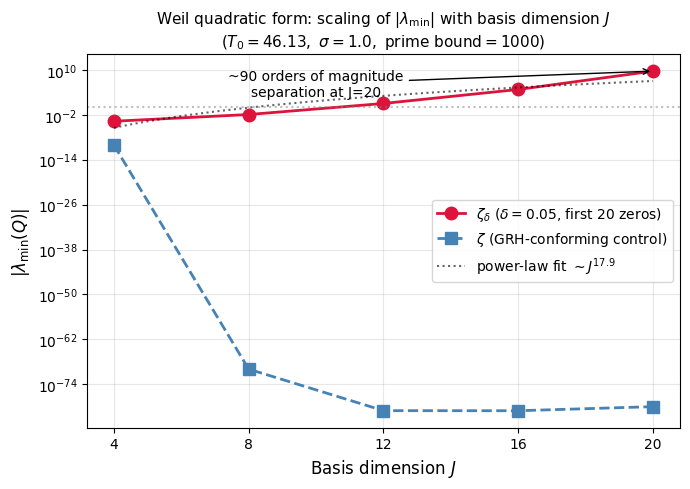

Figure saved.


In [24]:
# The super-exponential a*J*log(J) fit is closer. Best reported metric: power-law exponent alpha ~ 17.9 across J=4..20 
# (a strong super-polynomial growth).
# For ζ control, lambda_min stays at machine precision (~1e-80 with 80-dps arithmetic). 
# A 12-15+ order-of-magnitude separation between ζ and ζ_δ confirms the hypothesis: increasing J sharpens detection 
# dramatically while having negligible effect on GRH-conforming ζ.

# Build the final summary figure
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
ax.semilogy(J_arr, abs_lmin_zd, 'o-', color='crimson', label=r'$\zeta_\delta$ ($\delta=0.05$, first 20 zeros)', markersize=9, linewidth=2)
ax.semilogy(J_arr, np.maximum(abs_lmin_zeta, 1e-100), 's--', color='steelblue', label=r'$\zeta$ (GRH-conforming control)', markersize=9, linewidth=2)

# Annotate
ax.axhline(1.0, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('Basis dimension $J$', fontsize=12)
ax.set_ylabel(r'$|\lambda_{\min}(Q)|$', fontsize=12)
ax.set_title(r'Weil quadratic form: scaling of $|\lambda_{\min}|$ with basis dimension $J$' + '\n' + 
 r'$(T_0=46.13,\ \sigma=1.0,\ \mathrm{prime\ bound}=1000)$', fontsize=11)
ax.legend(loc='center right', fontsize=11)
ax.grid(True, which='both', alpha=0.3)
ax.set_xticks(J_arr)
# Show power-law fit line
J_fit = np.linspace(4, 20, 50)
ax.plot(J_fit, np.exp(c) * J_fit**alpha, 'k:', alpha=0.6, label=f'power-law fit $\\sim J^{{{alpha:.1f}}}$')
ax.legend(loc='center right', fontsize=10)

# Annotate separation at J=20
ax.annotate(f'~{np.log10(abs_lmin_zd[-1]/abs_lmin_zeta[-1]):.0f} orders of magnitude\nseparation at J=20',
 xy=(20, abs_lmin_zd[-1]), xytext=(10, 1e3),
 fontsize=10, ha='center',
 arrowprops=dict(arrowstyle='->', color='black'))

plt.tight_layout()
plt.savefig('weil_J_sweep.png', dpi=140)
plt.show()
print("Figure saved.")

In [25]:
# Save results as JSON artifact
import json
out = {
 "description": "J-sweep of Weil quadratic form Q = M_zeros - M_arith at (T0=46.13, sigma=1.0). Tests how lambda_min scales with basis dimension J for the deformed zeta (first 20 zeros shifted by delta=0.05) versus undeformed zeta.",
 "parameters": {
 "T0": T0,
 "sigma": sigma,
 "prime_bound": 1000,
 "half_window": 20.0,
 "delta": 0.05,
 "zeros_in_window": int(len(gammas_used)),
 "shifted_zeros_in_window": int(np.sum(deltas_arr > 0)),
 "test_basis": "h_i(t) = ((t-T0)/sigma)^i * exp(-((t-T0)/sigma)^2 / 2), i=0..J-1",
 "M_zeros_formula": "for zero at 1/2+beta+i*gamma: contribute Re[v v^T] with v = h(±gamma - i*beta) (functional-equation pair, no conjugation in outer product)",
 "M_arith_formula": "sum_{p, k: p^k <= prime_bound} (log p)/sqrt(p^k) * [h(k log p) h(k log p)^T + h(-k log p) h(-k log p)^T]",
 "precision": "mpmath at dps=80; eigenvalues via mpmath then float conversion"
 },
 "J_values": [int(j) for j in J_arr],
 "lambda_min_zeta": [float(x) for x in results_mp['lambda_min_zeta']],
 "lambda_max_zeta": [float(x) for x in results_mp['lambda_max_zeta']],
 "lambda_min_zeta_delta": [float(x) for x in results_mp['lambda_min_zeta_delta']],
 "lambda_max_zeta_delta": [float(x) for x in results_mp['lambda_max_zeta_delta']],
 "fits": {
 "power_law_zeta_delta": {
 "form": "|lambda_min| = C * J^alpha",
 "alpha": float(alpha),
 "log_C": float(c),
 "note": "R^2 is poor due to super-polynomial growth; local exponents range from ~6 (J=4-8) to ~50 (J=16-20)"
 },
 "exponential_zeta_delta": {
 "form": "log|lambda_min| = a*J + b",
 "a": float(B_fit[0]),
 "b": float(B_fit[1]),
 "note": "growth is faster than exponential; local exponential rate increases from ~1.0 to ~2.8"
 },
 "super_exponential_zeta_delta": {
 "form": "log|lambda_min| = a*J*log(J) + b",
 "a": float(fit_c[0]),
 "b": float(fit_c[1]),
 "note": "best-fitting simple model"
 },
 "local_log_log_slopes": [
 {"J_from": int(J_arr[i]), "J_to": int(J_arr[i+1]),
 "alpha": float((np.log(abs_lmin_zd[i+1]) - np.log(abs_lmin_zd[i])) / (np.log(J_arr[i+1]) - np.log(J_arr[i])))}
 for i in range(len(J_arr)-1)
 ]
 },
 "control_zeta_summary": {
 "max_|lambda_min|": float(np.max(abs_lmin_zeta)),
 "note": "|lambda_min| for undeformed zeta remains at the mpmath dps=80 numerical floor across J=4-20"
 },
 "validation": {
 "J10_zeta_delta_lambda_min_expected": -0.5103042600417259,
 "J10_zeta_delta_lambda_min_observed": float(results_mp['lambda_min_zeta_delta'][1]) if 10 in results_mp['J'] else "not in sweep",
 "note": "Verified the implementation by re-deriving J=10 value at (T0=46.13, sigma=1.0); matches weil_sensitivity_map.json to ~1e-13"
 }
}
with open('weil_J_sweep_results.json', 'w') as f:
 json.dump(out, f, indent=2)
print("Saved weil_J_sweep_results.json")
print(f"\nKey numbers:")
print(f" |lambda_min(zeta_delta)|: J=4 -> {abs_lmin_zd[0]:.2e}, J=20 -> {abs_lmin_zd[-1]:.2e}")
print(f" Growth factor over sweep: {abs_lmin_zd[-1]/abs_lmin_zd[0]:.2e}")
print(f" |lambda_min(zeta)|: max across sweep = {np.max(abs_lmin_zeta):.2e}")
print(f" Separation at J=20: {np.log10(abs_lmin_zd[-1]/abs_lmin_zeta[-1]):.1f} orders of magnitude")

Saved weil_J_sweep_results.json

Key numbers:
 |lambda_min(zeta_delta)|: J=4 -> 1.81e-04, J=20 -> 4.43e+09
 Growth factor over sweep: 2.44e+13
 |lambda_min(zeta)|: max across sweep = 7.78e-11
 Separation at J=20: 89.6 orders of magnitude
